In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%capture
!pip install -q "numpy<2" --force-reinstall

In [3]:
import numpy, torch, torchvision
# print("numpy:", numpy.__version__)
# print("torch:", torch.__version__)
# print("torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

CUDA: True


In [4]:
import os, glob, json, random

TRAIN_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/training_data"
VAL_DIR   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/validation_data"
TEST_DIR  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"

VAL_REF   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/validation_reference/reference.txt"
TEST_REF  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"

STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

# ═══════════════════════════════════════════════════
# TRAINING — training_data_final
# ═══════════════════════════════════════════════════
train_items = []
for ext in IMG_EXTS:
    for p in glob.glob(os.path.join(TRAIN_DIR, f"*{ext}")):
        name = os.path.basename(p).lower()
        if "_real" in name:
            train_items.append({"path": p, "label": 0})
        elif "_fake" in name:
            train_items.append({"path": p, "label": 1})

random.seed(42)
random.shuffle(train_items)

n_real = sum(1 for x in train_items if x["label"] == 0)
n_fake = sum(1 for x in train_items if x["label"] == 1)
print(f"TRAIN: {len(train_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# VALIDATION — validation_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(VAL_REF) as f:
    val_labels = [int(line.strip()) for line in f if line.strip()]

val_images = sorted(glob.glob(os.path.join(VAL_DIR, "*.*")))
val_images = [p for p in val_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(val_images) == len(val_labels), \
    f"Mismatch: {len(val_images)} images vs {len(val_labels)} labels"

val_items = [{"path": p, "label": l} for p, l in zip(val_images, val_labels)]

n_real = sum(1 for x in val_items if x["label"] == 0)
n_fake = sum(1 for x in val_items if x["label"] == 1)
print(f"VAL:   {len(val_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# TEST — publictest_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [p for p in test_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(test_images) == len(test_labels), \
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"

test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)
print(f"TEST:  {len(test_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# SAVE JSONs
# ═══════════════════════════════════════════════════
for name, data in [("train", train_items), ("val", val_items), ("test", test_items)]:
    out = os.path.join(STAGING, f"{name}.json")
    with open(out, "w") as f:
        json.dump(data, f)
    print(f"\n✓ {name}.json → {len(data)} items → {out}")


TRAIN: 1000 images  (real=500, fake=500)
VAL:   100 images  (real=50, fake=50)
TEST:  1000 images  (real=500, fake=500)

✓ train.json → 1000 items → /content/DiffusionForensics_Recons/train.json

✓ val.json → 100 items → /content/DiffusionForensics_Recons/val.json

✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [5]:
%%capture
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

In [6]:
%%capture
%cd "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub"
!head -n -1 requirements.txt > requirements_no_flash.txt
!pip install -r requirements_no_flash.txt

In [ ]:
# import shutil
# from pathlib import Path

# CKPT_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/resnet_train")

# if CKPT_DIR.exists():
#     shutil.rmtree(CKPT_DIR)
#     print("🧹 Old checkpoints deleted")

# CKPT_DIR.mkdir(parents=True, exist_ok=True)
# print("✅ Fresh checkpoint directory created:", CKPT_DIR)

🧹 Old checkpoints deleted
✅ Fresh checkpoint directory created: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/resnet_train


In [ ]:
# %cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub

# !PYTHONPATH=$PWD MASTER_ADDR=127.0.0.1 MASTER_PORT=29601 \
# python -m ForensicHub.training_scripts.train \
# --config "ForensicHub/statics/aigc/resnet_train.yaml"

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2.10.0+cu128
Current Torch version: 2.10
/usr/local/lib/python3.12/dist-packages/timm/optim/optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)
2026-04-17 14:14:52.396960: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776435292.433305    3542 cuda_dnn.cc:8579] Unable to register cuDNN fact

Best AUC: 0.5799 at epoch 20
F1 at best AUC epoch: 0.4810 at epoch 20


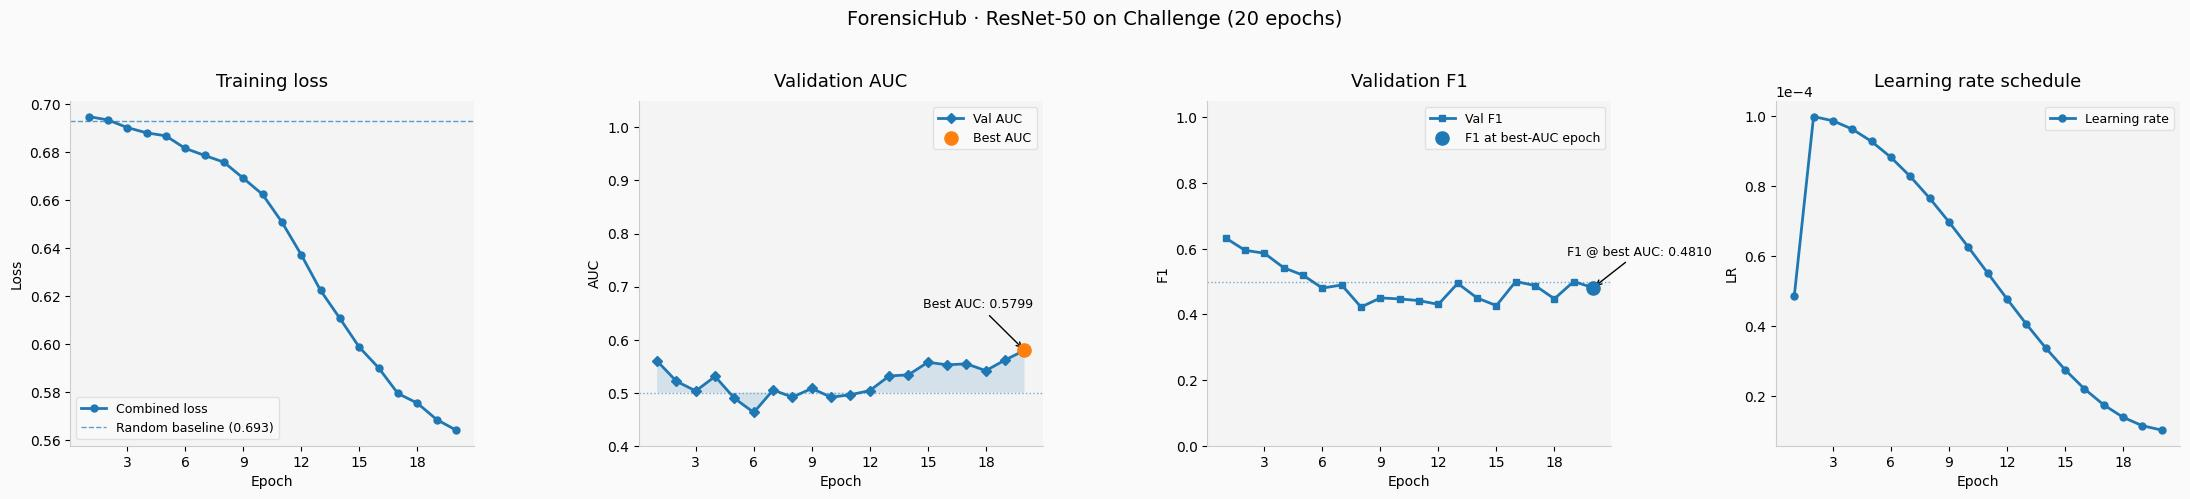

In [7]:
%matplotlib inline
import os, json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import Image, display

LOG_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/resnet_train/log.txt"


def parse_forensichub_resnet_json_log(path):
    all_entries = []

    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "epoch" in entry:
                all_entries.append(entry)

    if not all_entries:
        raise RuntimeError(f"No JSON epoch entries found in {path}")

    # Use only the last run if the log contains restarted runs
    runs = []
    current_run = []
    prev_epoch = -1

    for entry in all_entries:
        ep = int(entry.get("epoch", 0))

        if ep <= prev_epoch and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(entry)
        prev_epoch = ep

    if current_run:
        runs.append(current_run)

    entries = runs[-1]

    # Match SPSL style: display epochs as 1-based
    epochs = [int(e["epoch"]) + 1 for e in entries]

    train_losses = [
        float(e.get("train_combined_loss", e.get("train_overall", np.nan)))
        for e in entries
    ]

    lrs = [
        float(e.get("train_lr", np.nan))
        for e in entries
    ]

    test_aucs = [
        float(e.get("test_image-level AUC", np.nan))
        for e in entries
    ]

    test_f1s = [
        float(e.get("test_image-level F1", np.nan))
        for e in entries
    ]

    train_aucs = [
        float(e.get("traineval_image-level AUC", np.nan))
        for e in entries
    ]

    train_f1s = [
        float(e.get("traineval_image-level F1", np.nan))
        for e in entries
    ]

    return epochs, train_losses, lrs, test_aucs, test_f1s, train_aucs, train_f1s, len(runs)


def plot_training(path):
    epochs, losses, lrs, aucs, f1s, train_aucs, train_f1s, n_runs = parse_forensichub_resnet_json_log(path)

    aucs_np = np.array(aucs, dtype=float)

    best_auc_idx = int(np.nanargmax(aucs_np))

    best_auc_epoch = epochs[best_auc_idx]
    best_auc = aucs[best_auc_idx]
    f1_at_best_auc = f1s[best_auc_idx]

    print(f"Best AUC: {best_auc:.4f} at epoch {best_auc_epoch}")
    print(f"F1 at best AUC epoch: {f1_at_best_auc:.4f} at epoch {best_auc_epoch}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.8))
    fig.patch.set_facecolor("#FAFAFA")

    for ax in axes:
        ax.set_facecolor("#F4F4F4")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # 1. Training loss
    ax = axes[0]
    ax.plot(
        epochs,
        losses,
        marker="o",
        linewidth=2,
        markersize=5,
        label="Combined loss",
    )
    ax.axhline(
        0.693,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="Random baseline (0.693)",
    )
    ax.set_title("Training loss", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9, framealpha=0.5)

    # 2. Validation AUC
    ax = axes[1]
    ax.plot(
        epochs,
        aucs,
        marker="D",
        linewidth=2,
        markersize=5,
        label="Val AUC",
    )
    ax.fill_between(epochs, 0.5, aucs, alpha=0.15)

    if not np.all(np.isnan(train_aucs)):
        ax.plot(
            epochs,
            train_aucs,
            marker="o",
            linewidth=1.8,
            markersize=4,
            alpha=0.8,
            label="Train AUC",
        )

    ax.scatter(best_auc_epoch, best_auc, s=90, zorder=5, label="Best AUC")
    ax.annotate(
        f"Best AUC: {best_auc:.4f}",
        xy=(best_auc_epoch, best_auc),
        xytext=(best_auc_epoch - max(epochs) * 0.12, best_auc + 0.08),
        fontsize=9,
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1),
    )
    ax.axhline(0.5, linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0.4, 1.05)
    ax.set_title("Validation AUC", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("AUC")
    ax.legend(fontsize=9, framealpha=0.5)

    # 3. Validation F1 at best-AUC epoch
    ax = axes[2]
    ax.plot(
        epochs,
        f1s,
        marker="s",
        linewidth=2,
        markersize=5,
        label="Val F1",
    )

    if not np.all(np.isnan(train_f1s)):
        ax.plot(
            epochs,
            train_f1s,
            marker="o",
            linewidth=1.8,
            markersize=4,
            alpha=0.8,
            label="Train F1",
        )

    ax.scatter(
        best_auc_epoch,
        f1_at_best_auc,
        s=90,
        zorder=5,
        label="F1 at best-AUC epoch",
    )
    ax.annotate(
        f"F1 @ best AUC: {f1_at_best_auc:.4f}",
        xy=(best_auc_epoch, f1_at_best_auc),
        xytext=(best_auc_epoch + max(epochs) * 0.12, f1_at_best_auc + 0.10),
        fontsize=9,
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1),
    )
    ax.axhline(0.5, linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_title("Validation F1", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1")
    ax.legend(fontsize=9, framealpha=0.5)

    # 4. Learning rate
    ax = axes[3]
    ax.plot(
        epochs,
        lrs,
        marker="o",
        linewidth=2,
        markersize=5,
        label="Learning rate",
    )
    ax.set_title("Learning rate schedule", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR")
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.legend(fontsize=9, framealpha=0.5)

    plt.suptitle(
        f"ForensicHub · ResNet-50 on Challenge ({len(epochs)} epochs)",
        fontsize=14,
        y=1.03,
    )
    plt.tight_layout()

    out_path = "forensichub_resnet_training_curves.jpg"
    plt.savefig(out_path, dpi=100, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)

    display(Image(out_path))


plot_training(LOG_PATH)

In [8]:
# model
import os
import json
import torch
from PIL import Image
from torchvision import transforms
from ForensicHub.registry import MODELS, build_from_registry

# ── Paths / constants ─────────────────────────────────────────────────────────
CHECKPOINT_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/resnet_train"
VAL_JSON = "/content/DiffusionForensics_Recons/val.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.5


# ── Step 1: find best epoch automatically from log.txt by best AUC ────────────
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

all_entries = []

with open(LOG_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        try:
            entry = json.loads(line)
        except Exception:
            continue

        if "epoch" in entry:
            all_entries.append(entry)

runs, current_run, prev_epoch = [], [], -1

for entry in all_entries:
    ep = int(entry.get("epoch", 0))

    if ep <= prev_epoch and current_run:
        runs.append(current_run)
        current_run = []

    current_run.append(entry)
    prev_epoch = ep

if current_run:
    runs.append(current_run)

if not runs:
    raise RuntimeError(f"No valid log runs found in {LOG_PATH}")

last_run = runs[-1]

# Choose best checkpoint metadata by validation AUC, like SPSL
valid_auc_entries = [
    e for e in last_run
    if e.get("test_image-level AUC") is not None
]

if not valid_auc_entries:
    raise RuntimeError(f"No validation AUC entries found in last run of {LOG_PATH}")

best_entry = max(
    valid_auc_entries,
    key=lambda e: float(e["test_image-level AUC"])
)

best_epoch = int(best_entry["epoch"])
best_auc = float(best_entry["test_image-level AUC"])
best_f1 = float(best_entry.get("test_image-level F1", float("nan")))

print(f"Best epoch from log by AUC: {best_epoch}")
print(f"Best val AUC: {best_auc:.6f}")
print(f"Val F1 at best-AUC epoch: {best_f1:.6f}")


# ── Step 2: select checkpoint ─────────────────────────────────────────────────
best_ckpt = os.path.join(CHECKPOINT_DIR, f"checkpoint-{best_epoch}.pth")

if not os.path.exists(best_ckpt):
    available = sorted(
        [
            f for f in os.listdir(CHECKPOINT_DIR)
            if f.startswith("checkpoint-") and f.endswith(".pth")
        ],
        key=lambda f: int(f.replace("checkpoint-", "").replace(".pth", ""))
    )

    if not available:
        raise FileNotFoundError(f"No checkpoint files found in {CHECKPOINT_DIR}")

    candidates = [
        f for f in available
        if int(f.replace("checkpoint-", "").replace(".pth", "")) <= best_epoch
    ]

    best_ckpt = os.path.join(
        CHECKPOINT_DIR,
        candidates[-1] if candidates else available[-1]
    )

print("Using checkpoint:")
print(best_ckpt)


# ── Step 3: build exact ForensicHub model from registry ───────────────────────
model_args = {
    "name": "Resnet50",
    "init_config": {
        "output_type": "label",
        "pretrained": False,
        "image_size": 224,
    }
}

model = build_from_registry(MODELS, model_args)

checkpoint = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model"] if "model" in checkpoint else checkpoint

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print(f"Missing keys: {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")

if len(missing) > 0:
    print("First missing keys:", missing[:10])

if len(unexpected) > 0:
    print("First unexpected keys:", unexpected[:10])

model.to(DEVICE)
model.eval()


# ── Step 4: validation transform ──────────────────────────────────────────────
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# ── Step 5: load validation items and run inference ───────────────────────────
with open(VAL_JSON) as f:
    val_items = json.load(f)

results = []
skipped = []

with torch.no_grad():
    for item in val_items:
        path = item["path"]
        label = item["label"]

        try:
            image_tensor = val_transform(
                Image.open(path).convert("RGB")
            ).unsqueeze(0).to(DEVICE)

            input_dict = {
                "image": image_tensor,
                "label": torch.tensor([label], dtype=torch.float32).to(DEVICE),
                "mask": torch.ones(1, 1, 224, 224).to(DEVICE),
            }

            out_dict = model(**input_dict)
            prob = out_dict["pred_label"].view(-1)[0].item()
            pred = 1 if prob >= THRESHOLD else 0

            results.append({
                "path": path,
                "true_label": int(label),
                "pred": int(pred),
                "confidence": float(prob),
                "correct": bool(pred == label),

                # Metadata from log.txt best-AUC epoch, for SPSL-style CM cell
                "checkpoint_epoch": best_epoch,
                "checkpoint_val_auc": best_auc,
                "checkpoint_val_f1": best_f1,
                "checkpoint_file": best_ckpt,
            })

        except Exception as e:
            skipped.append({
                "path": path,
                "error": str(e),
            })

if len(results) == 0:
    print("First skipped errors:")
    for s in skipped[:10]:
        print(s)

    raise RuntimeError("No validation images were processed successfully.")

print(f"Processed: {len(results)}")
print(f"Skipped: {len(skipped)}")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


2.10.0+cu128
Current Torch version: 2.10
Best epoch from log by AUC: 19
Best val AUC: 0.579861
Val F1 at best-AUC epoch: 0.481013
Using checkpoint:
/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/resnet_train/checkpoint-19.pth
[build_from_registry] Creating model 'Resnet50' with args: {'output_type': 'label', 'pretrained': False, 'image_size': 224}
Missing keys: 0
Unexpected keys: 0
Processed: 100
Skipped: 0


In [9]:
# ── Inference on TRAINING set (same model, already loaded) ──
TRAIN_JSON = "/content/DiffusionForensics_Recons/train.json"

with open(TRAIN_JSON) as f:
    train_items = json.load(f)

print(f"Running inference on {len(train_items)} training images...")

train_results = []

with torch.no_grad():
    for i, item in enumerate(train_items):
        path  = item["path"]
        label = item["label"]

        try:
            image_tensor = val_transform(
                Image.open(path).convert("RGB")
            ).unsqueeze(0).to(DEVICE)

            input_dict = {
                "image": image_tensor,
                "label": torch.tensor([label], dtype=torch.float32).to(DEVICE),
                "mask":  torch.ones(1, 1, 224, 224).to(DEVICE),
            }

            out_dict = model(**input_dict)
            prob = out_dict["pred_label"].view(-1)[0].item()
            pred = 1 if prob >= THRESHOLD else 0

            train_results.append({
                "path":       path,
                "true_label": int(label),
                "pred":       int(pred),
                "confidence": float(prob),
                "correct":    bool(pred == label),
            })
        except:
            continue

        if (i+1) % 500 == 0:
            print(f"  {i+1}/{len(train_items)}...")

train_acc = 100 * sum(r["correct"] for r in train_results) / len(train_results)
print(f"Done: {len(train_results)} images, Train accuracy: {train_acc:.1f}%")


Running inference on 1000 training images...
  500/1000...
  1000/1000...
Done: 1000 images, Train accuracy: 80.4%


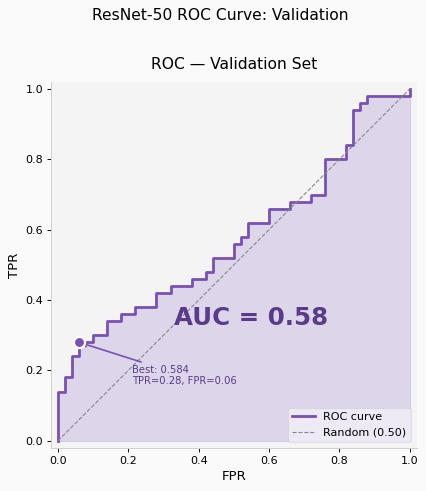


Validation AUC: 0.5764  |  Best threshold: 0.5840


In [10]:
# ── ROC Curve: Validation only ──
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from IPython.display import Image, display

# Validation ROC
y_true_val  = np.array([r["true_label"] for r in results])
y_score_val = np.array([r["confidence"] for r in results])

fpr_val, tpr_val, thresh_val = roc_curve(y_true_val, y_score_val)
auc_val = auc(fpr_val, tpr_val)

fig, ax = plt.subplots(figsize=(6.5, 6))
fig.patch.set_facecolor('#FAFAFA')

ax.set_facecolor('#F4F4F4')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.set_aspect('equal')

ax.plot(fpr_val, tpr_val, color='#7B4FB5', linewidth=2.5, label='ROC curve')
ax.fill_between(fpr_val, tpr_val, alpha=0.25, color='#9B7FD4')
ax.text(0.55, 0.35, f'AUC = {auc_val:.2f}', fontsize=22,
        fontweight='bold', color='#5A3A8A', ha='center', va='center')

ax.plot([0, 1], [0, 1], color='#888', linestyle='--', linewidth=1,
        label='Random (0.50)')

opt_val = np.argmax(tpr_val - fpr_val)
ax.scatter(fpr_val[opt_val], tpr_val[opt_val], color='#7B4FB5',
           s=100, zorder=5, edgecolors='white', linewidths=2)
ax.annotate(f'Best: {thresh_val[opt_val]:.3f}\n'
            f'TPR={tpr_val[opt_val]:.2f}, FPR={fpr_val[opt_val]:.2f}',
            xy=(fpr_val[opt_val], tpr_val[opt_val]),
            xytext=(fpr_val[opt_val] + 0.15, tpr_val[opt_val] - 0.12),
            fontsize=9, color='#5A3A8A',
            arrowprops=dict(arrowstyle='->', color='#7B4FB5', lw=1.5))

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('FPR', fontsize=12)
ax.set_ylabel('TPR', fontsize=12)
ax.set_title('ROC — Validation Set', fontsize=14, pad=12)
ax.legend(fontsize=10, loc='lower right', framealpha=0.5)

plt.suptitle('ResNet-50 ROC Curve: Validation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('roc_val.jpg', dpi=80, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close(fig)
display(Image('roc_val.jpg'))

print(f"\nValidation AUC: {auc_val:.4f}  |  Best threshold: {thresh_val[opt_val]:.4f}")

════════════════════════════════════════════════════════════
  Validation Metrics — ResNet-50
════════════════════════════════════════════════════════════
  Selected checkpoint epoch: 19
  AUC Best Epoch:     0.5799
  F1 Best-AUC epoch:  0.4810
  Accuracy:           0.5500
────────────────────────────────────────────────────────────
  TP (correct fake):         19
  TN (correct real):         36
  FP (false alarm):          14
  FN (missed fake):          31
════════════════════════════════════════════════════════════


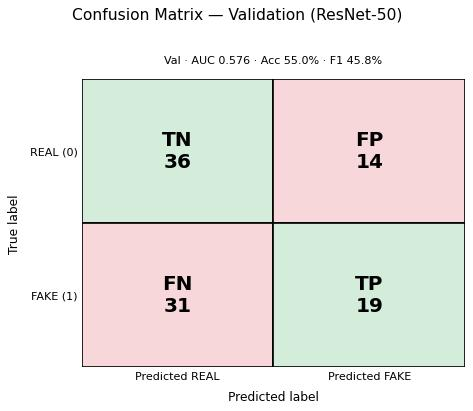

In [11]:
# ── Confusion Matrix: Validation only, ResNet-50 — best-AUC checkpoint results ──
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from IPython.display import Image, display

MODEL_NAME = "ResNet-50"

def compute_metrics(res):
    y_true = np.array([int(r["true_label"]) for r in res])
    y_pred = np.array([int(r["pred"]) for r in res])

    # Some cells use "confidence", others use "score"
    if "confidence" in res[0]:
        y_score = np.array([float(r["confidence"]) for r in res])
    elif "score" in res[0]:
        y_score = np.array([float(r["score"]) for r in res])
    else:
        raise KeyError("results must contain either 'confidence' or 'score'.")

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    auc_direct = roc_auc_score(y_true, y_score)
    auc_inverted = roc_auc_score(y_true, 1.0 - y_score)

    # Use the direction that gives correct fake-probability ranking
    if auc_inverted > auc_direct:
        auc_val = auc_inverted
        score_mode = "1 - score"
    else:
        auc_val = auc_direct
        score_mode = "score"

    return TN, FP, FN, TP, accuracy, precision, recall, f1, auc_val, score_mode

def draw_cm(ax, TN, FP, FN, TP, title):
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    cell_values = [[TN, FP], [FN, TP]]
    cell_colors = [["#d4edda", "#f8d7da"],
                   ["#f8d7da", "#d4edda"]]

    for i in range(2):
        for j in range(2):
            ax.add_patch(
                plt.Rectangle(
                    (j, 1 - i), 1, 1,
                    facecolor=cell_colors[i][j],
                    edgecolor="black",
                    linewidth=1.5
                )
            )
            ax.text(
                j + 0.5,
                1 - i + 0.5,
                f"{cell_labels[i][j]}\n{cell_values[i][j]}",
                ha="center",
                va="center",
                fontsize=18,
                fontweight="bold",
                color="black"
            )

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([1.5, 0.5])

    ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=10)
    ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=10)

    ax.set_xlabel("Predicted label", fontsize=11, labelpad=8)
    ax.set_ylabel("True label", fontsize=11, labelpad=8)

    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=10, pad=14)

# Safety check
if len(results) == 0:
    raise RuntimeError("Validation results is empty.")

TN, FP, FN, TP, acc, prec, rec, f1, auc_val, score_mode = compute_metrics(results)

# Optional: pull checkpoint metadata if your results include it
ckpt_epoch = results[0].get("checkpoint_epoch", None)
ckpt_val_auc = results[0].get("checkpoint_val_auc", None)
ckpt_val_f1 = results[0].get("checkpoint_val_f1", None)

print(f"{'═' * 60}")
print(f"  Validation Metrics — {MODEL_NAME}")
print(f"{'═' * 60}")

if ckpt_epoch is not None:
    print(f"  Selected checkpoint epoch: {ckpt_epoch}")
if ckpt_val_auc is not None:
    print(f"  AUC Best Epoch:     {float(ckpt_val_auc):.4f}")
if ckpt_val_f1 is not None:
    print(f"  F1 Best-AUC epoch:  {float(ckpt_val_f1):.4f}")
print(f"  Accuracy:           {acc:.4f}")
print(f"{'─' * 60}")
print(f"  TP (correct fake):         {TP}")
print(f"  TN (correct real):         {TN}")
print(f"  FP (false alarm):          {FP}")
print(f"  FN (missed fake):          {FN}")
print(f"{'═' * 60}")

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

draw_cm(
    ax,
    TN, FP, FN, TP,
    f"Val · AUC {auc_val:.3f} · Acc {acc * 100:.1f}% · F1 {f1 * 100:.1f}%"
)

plt.suptitle(f"Confusion Matrix — Validation ({MODEL_NAME})", fontsize=14, y=1.02)
plt.tight_layout()

out_path = "confusion_matrix_val_resnet50.jpg"
plt.savefig(out_path, dpi=80, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

display(Image(out_path))

Done: 55/100 correct (55.0% accuracy)
REAL images: 50
FAKE images: 50
Well detected:  55
Badly detected: 45
TP=19, TN=36, FP=14, FN=31

REAL accuracy: 72.00%
FAKE accuracy: 38.00%
FAKE precision: 0.5758
FAKE recall: 0.3800
FAKE F1: 0.4578

── Per-dataset breakdown ──
   Challenge: 55/100 correct (55.0%)


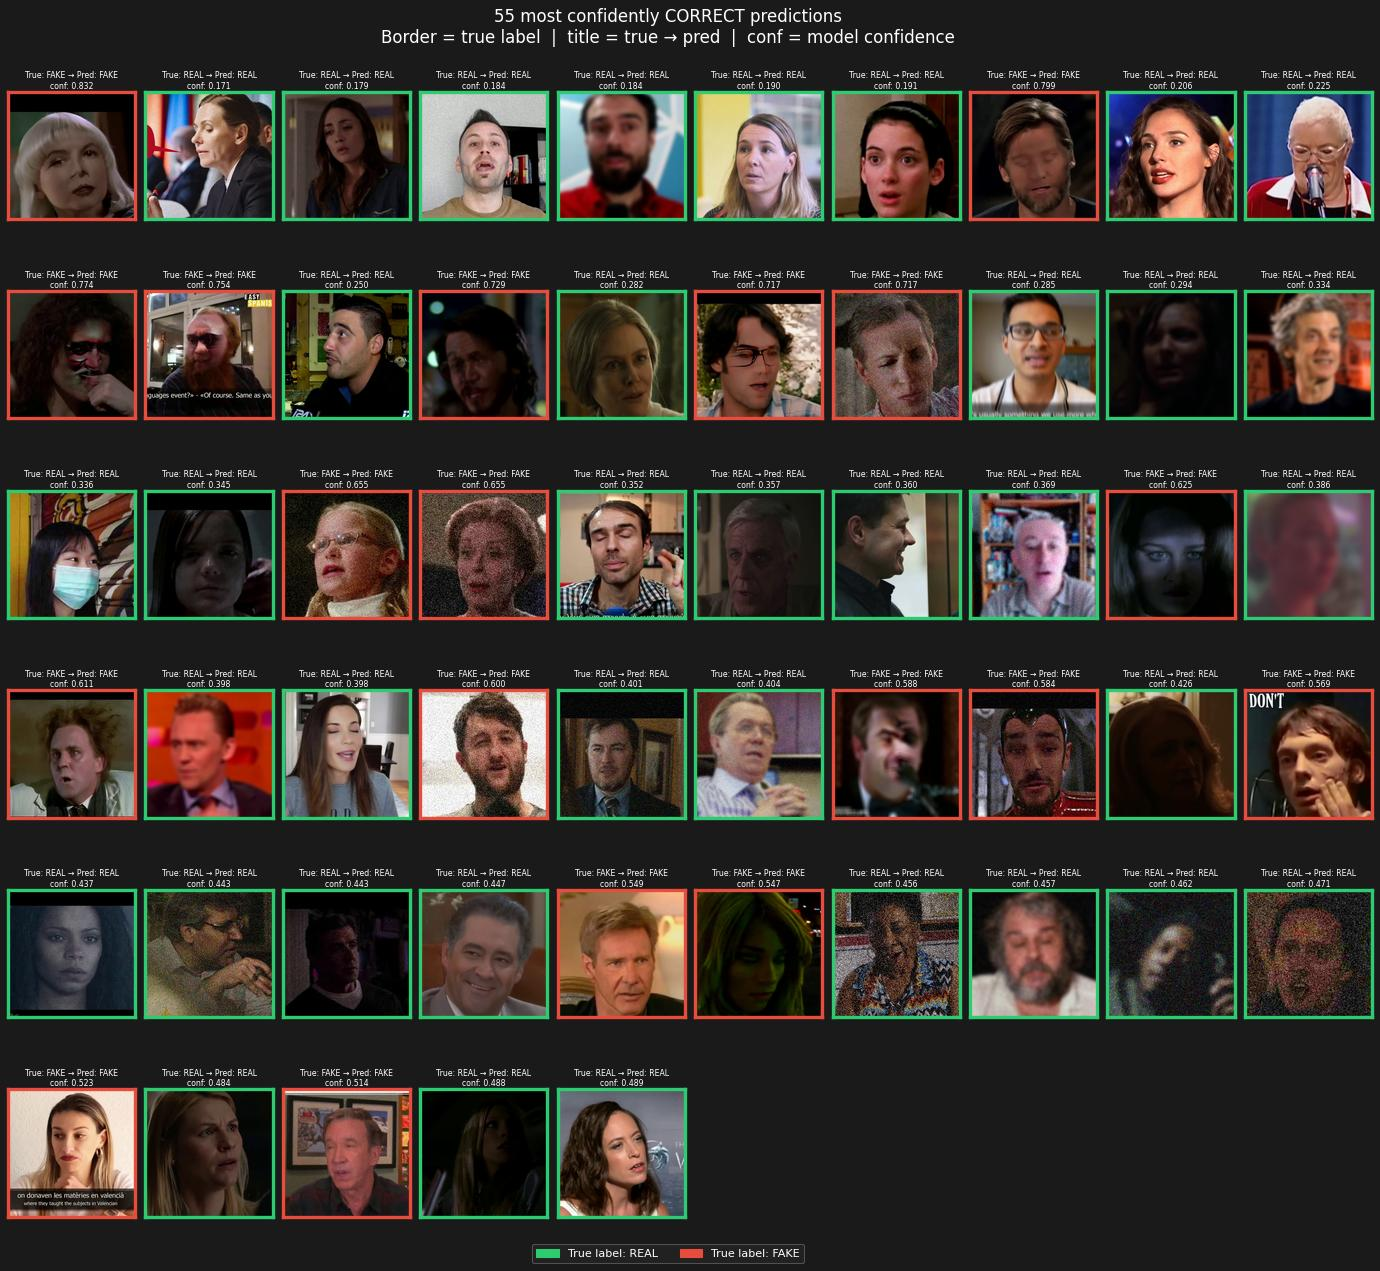

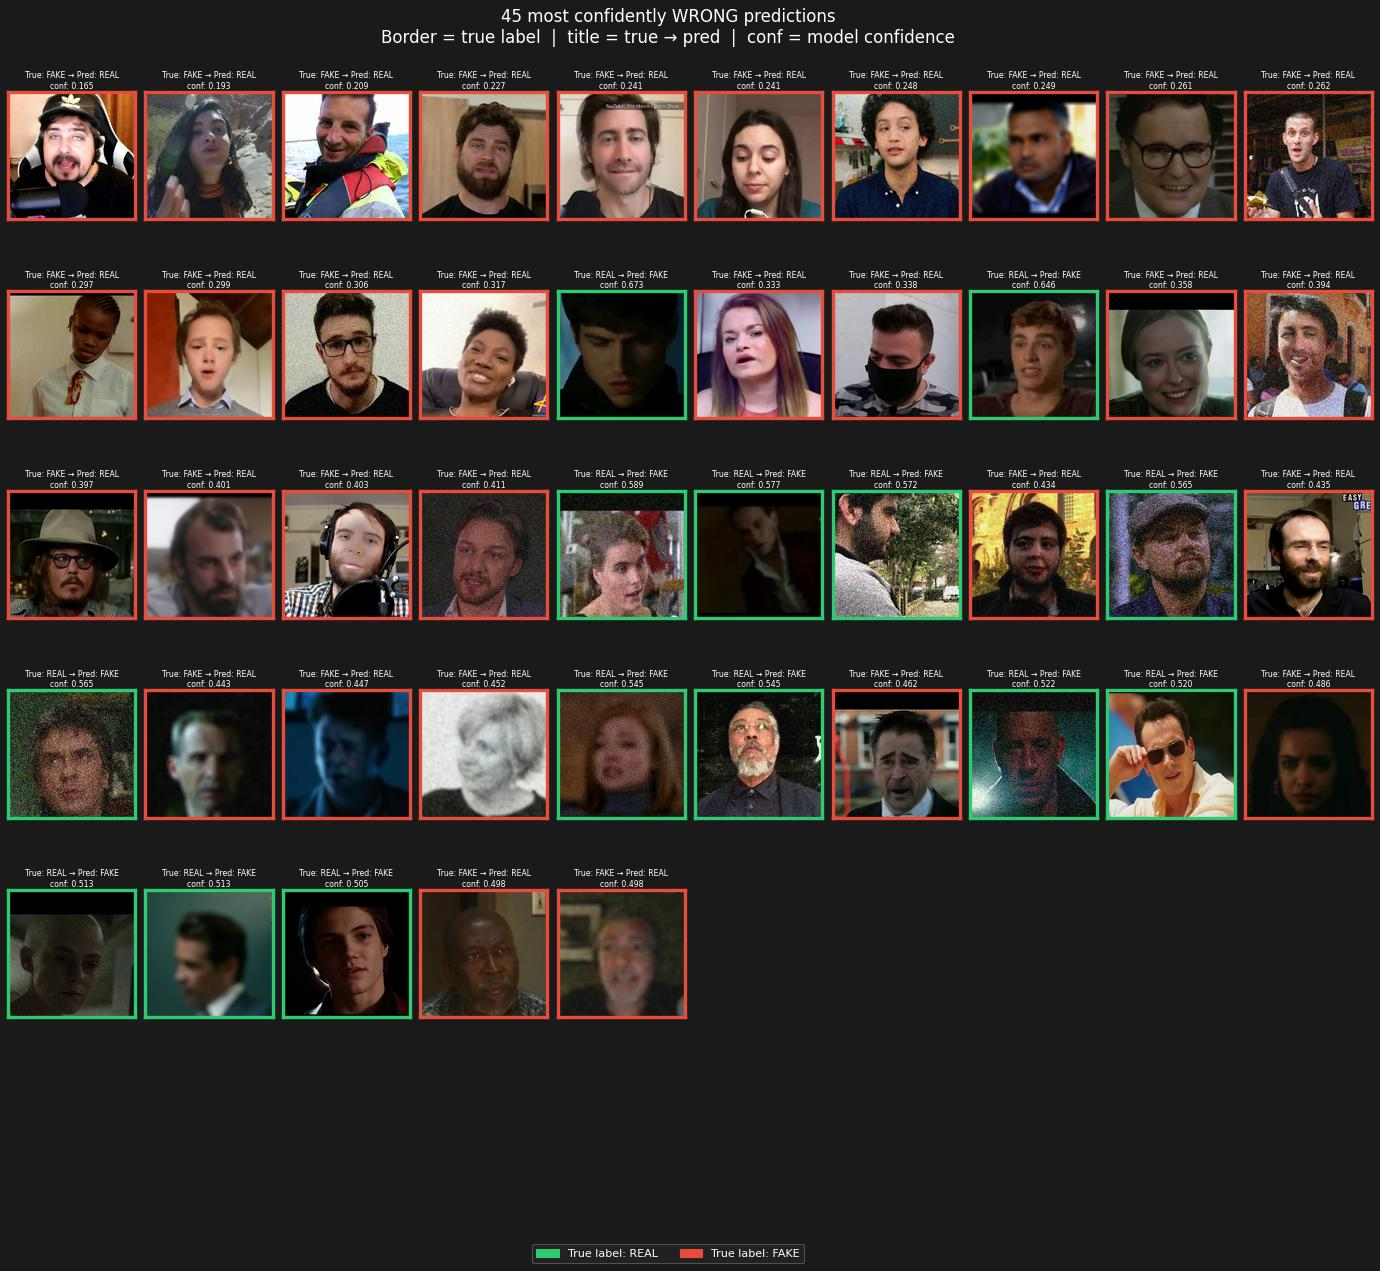

In [12]:
# Badly / Well Detected dataset

%matplotlib inline

import os
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

# ── Rebuild all summary information from `results` ────────────────────────────
total = len(results)
n_correct = sum(r["correct"] for r in results)
accuracy = 100 * n_correct / total

probs = [r["confidence"] for r in results]

well  = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

well_sorted  = sorted(well,  key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

well_sample  = well_sorted[:100]
badly_sample = badly_sorted[:100]

n_real = sum(r["true_label"] == 0 for r in results)
n_fake = sum(r["true_label"] == 1 for r in results)

tp = sum((r["true_label"] == 1 and r["pred"] == 1) for r in results)
tn = sum((r["true_label"] == 0 and r["pred"] == 0) for r in results)
fp = sum((r["true_label"] == 0 and r["pred"] == 1) for r in results)
fn = sum((r["true_label"] == 1 and r["pred"] == 0) for r in results)

real_acc = 100 * tn / max(1, n_real)
fake_acc = 100 * tp / max(1, n_fake)
precision_fake = tp / max(1, tp + fp)
recall_fake = tp / max(1, tp + fn)
f1_fake = 2 * precision_fake * recall_fake / max(1e-12, precision_fake + recall_fake)

# ── Print Dataset info ────────────────────────────────────────────────────────
# print(f"Running inference on {total} images...\n")
print(f"Done: {n_correct}/{total} correct ({accuracy:.1f}% accuracy)")
# print(f"Min prob: {min(probs):.4f}  Max: {max(probs):.4f}  Mean: {sum(probs)/len(probs):.4f}")
print(f"REAL images: {n_real}")
print(f"FAKE images: {n_fake}")
print(f"Well detected:  {len(well)}")
print(f"Badly detected: {len(badly)}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")

print(f"\nREAL accuracy: {real_acc:.2f}%")
print(f"FAKE accuracy: {fake_acc:.2f}%")
print(f"FAKE precision: {precision_fake:.4f}")
print(f"FAKE recall: {recall_fake:.4f}")
print(f"FAKE F1: {f1_fake:.4f}")

# ── Per-dataset breakdown ─────────────────────────────────────────────────────
DF40_FAKE_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/df40_fakes"
HIDF_REAL_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/hidf_files/real_images/Real-img"

def get_source(path):
    if DF40_FAKE_DIR in path:
        return "DF40"
    elif HIDF_REAL_DIR in path:
        return "HiDF"
    else:
        return "Challenge"

print(f"\n── Per-dataset breakdown ──")
for src_name in ["Challenge", "DF40", "HiDF"]:
    src_results = [r for r in results if get_source(r["path"]) == src_name]
    if not src_results:
        continue
    src_correct = sum(r["correct"] for r in src_results)
    src_acc = 100 * src_correct / len(src_results)
    print(f"  {src_name:>10}: {src_correct}/{len(src_results)} correct ({src_acc:.1f}%)")

if len(skipped) > 0:
    print(f"\nSkipped images: {len(skipped)}")
    for s in skipped[:10]:
        print(f"  {os.path.basename(s['path'])}: {s['error']}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def label_str(l):
    return "REAL" if l == 0 else "FAKE"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop(((w - side) // 2, (h - side) // 2,
                    (w + side) // 2, (h + side) // 2))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename):
    fig, axes = plt.subplots(6, 10, figsize=(22, 16))
    fig.patch.set_facecolor('#1a1a1a')
    fig.suptitle(title, fontsize=15, color='white', y=0.995, fontweight='medium')

    for idx, ax in enumerate(axes.flat):
        if idx >= len(samples):
            ax.axis('off')
            continue

        r = samples[idx]
        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'error', ha='center', va='center',
                    color='white', fontsize=7, transform=ax.transAxes)

        true_color = '#2ecc71' if r["true_label"] == 0 else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([]); ax.set_yticks([])

        src = get_source(r["path"])
        src_tag = f" [{src}]" if src != "Challenge" else ""
        ax.set_title(
            f"True: {label_str(r['true_label'])} → Pred: {label_str(r['pred'])}{src_tag}\n"
            f"conf: {r['confidence']:.3f}",
            fontsize=7, color='white', pad=3
        )

    real_p = mpatches.Patch(color='#2ecc71', label='True label: REAL')
    fake_p = mpatches.Patch(color='#e74c3c', label='True label: FAKE')
    fig.legend(handles=[real_p, fake_p], loc='lower center', ncol=2,
               fontsize=10, framealpha=0.3, facecolor='#333',
               labelcolor='white', bbox_to_anchor=(0.5, 0.01))

    plt.subplots_adjust(hspace=0.55, wspace=0.08, top=0.93, bottom=0.05)

    plt.savefig(filename, dpi=80, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    display(Image(filename))


# ── Plots ─────────────────────────────────────────────────────────────────────
make_grid(
    well_sample,
    title=f'{len(well_sample)} most confidently CORRECT predictions\n'
          'Border = true label  |  title = true → pred  |  conf = model confidence',
    filename='well_detected.jpg'
)

make_grid(
    badly_sample,
    title=f'{len(badly_sample)} most confidently WRONG predictions\n'
          'Border = true label  |  title = true → pred  |  conf = model confidence',
    filename='badly_detected.jpg'
)


In [14]:
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Resnet Train.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Resnet Train.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 1353216 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/Resnet Train.html
Done — check your Drive for the .html file
